In [20]:
import time as clock
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange
from IPython.display import clear_output, display
from torch.utils.data import TensorDataset, DataLoader
import sys
current_dir = os.path.dirname(os.path.abspath(__file__))
root_dir = os.path.join(current_dir, '..')
sys.path.append(root_dir)
from loss_balancong_algorithms.relobralo import ReLoBRaLo


$\frac{\partial T}{\partial t} - \frac{{\partial}^2 T}{\partial x^2} = 0$

$ T(t, x) = 2 + e^{-4 \pi^2 t} sin(2\pi x) + e^{-16\pi^2 t} cos(4\pi x)$, $x\in[0,1], t\in[0, 0.05]$

$\\$$T_0 = T(0, x) = 2 + sin(2\pi x) + cos(4\pi x)$

$ T(t, 0) = T(t, 1) = 2 + e^{-16\pi^2 t}$

In [21]:
def thermal_conductivity_equation(x):
    return (2 + torch.exp(-4*(torch.pi**2)*x[0])*torch.sin(2*torch.pi*x[1]) + torch.exp(-16*(torch.pi**2)*x[0])*torch.cos(4*torch.pi*x[1]))

def check_current_situation(cur_model, t=0):
    x = torch.linspace(0, 1, 100)
    time = t * torch.ones(100)
    real_temp = thermal_conductivity_equation([time, x])

    test_points = torch.stack((time, x), axis = -1)

    pinn_temp = cur_model(test_points)

    plt.plot(x.detach(), pinn_temp.cpu().detach(), label=f'PINN prediction with t = {t}')
    plt.plot(x, real_temp, label=f'Analytical solution with t = {t}')
    plt.grid()
    plt.xlabel('x')
    plt.ylabel(f'T(t={t}, x)')

    plt.plot()
    plt.legend()
    plt.show()

In [22]:
DEVICE = 'cpu'

In [23]:
# x_50 = torch.rand(50).requires_grad_(True).to(DEVICE)
# t_50 = 0.05 * torch.rand(50).requires_grad_(True).to(DEVICE)
# torch.save(x_50, 'x_50.pt')
# torch.save(t_50, 't_50.pt')

# x_100 = torch.rand(100).requires_grad_(True).to(DEVICE)
# t_100 = 0.05 * torch.rand(100).requires_grad_(True).to(DEVICE)
# torch.save(x_100, 'x_100.pt')
# torch.save(t_100, 't_100.pt')

# x_200 = torch.rand(200).requires_grad_(True).to(DEVICE)
# t_200 = 0.05 * torch.rand(200).requires_grad_(True).to(DEVICE)
# torch.save(x_200, 'x_200.pt')
# torch.save(t_200, 't_200.pt')

# x_500 = torch.rand(500).requires_grad_(True).to(DEVICE)
# t_500 = 0.05 * torch.rand(500).requires_grad_(True).to(DEVICE)
# torch.save(x_500, 'x_500.pt')
# torch.save(t_500, 't_500.pt')

# x_1000 = torch.rand(1000).requires_grad_(True).to(DEVICE)
# t_1000 = 0.05 * torch.rand(1000).requires_grad_(True).to(DEVICE)
# torch.save(x_1000, 'x_1000.pt')
# torch.save(t_1000, 't_1000.pt')

# x_5000 = torch.rand(5000).requires_grad_(True).to(DEVICE)
# t_5000 = 0.05 * torch.rand(5000).requires_grad_(True).to(DEVICE)
# torch.save(x_5000, 'x_5000.pt')
# torch.save(t_5000, 't_5000.pt')

In [24]:
# 200 500 1_000 5_000
N = 50

In [25]:
x_physics = torch.load(f'data/x_{N}.pt').requires_grad_(True).to(DEVICE)
time_physics = torch.load(f'data/t_{N}.pt').requires_grad_(True).to(DEVICE)

In [26]:
# x_physics = torch.rand(N).requires_grad_(True).to(DEVICE)
# time_physics = 0.05 * torch.rand(N).requires_grad_(True).to(DEVICE)
points_for_pinn_model = torch.stack((time_physics, x_physics), -1).to(DEVICE)
boundary_condition_points = torch.stack((torch.zeros(N).to(DEVICE), x_physics), -1).to(DEVICE)
periodic_points_x0 = torch.stack((time_physics, torch.zeros(N).to(DEVICE)), -1).to(DEVICE)
periodic_points_x1 = torch.stack((time_physics, torch.ones(N).to(DEVICE)), -1).to(DEVICE)

In [27]:
# class PINN(nn.Module):
#     def __init__(self, input_dim=2, hidden_dim=128, num_layers=16, output_dim=1):
#         super().__init__()

#         self.input_layer = nn.Linear(input_dim, hidden_dim)
#         self.hidden_layers = nn.ModuleList(
#             [nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)]
#         )
#         self.output_layer = nn.Linear(hidden_dim, output_dim)

#         self._init_weights()

#     def _init_weights(self):
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)

#     def forward(self, x):
#         h = torch.relu(self.input_layer(x))
#         for i, layer in enumerate(self.hidden_layers):
#             h_new = torch.relu(layer(h))
#             if i % 2 == 1:
#                 h = h + h_new
#             else:
#                 h = h_new
#         T = self.output_layer(h)
#         return T
# class PINN(nn.Module):
#     def __init__(self, input_layer = 2, hidden_layer = 32, number_layers = 6, output_layer = 1):
#         super().__init__()
        
#         self.activation1 = nn.ReLU
#         self.activation2 = nn.ReLU()
        
#         self.fcs = nn.Sequential(*
#             [
#                 nn.Linear(input_layer, hidden_layer),
#                 self.activation1()
#             ]
#         )
        
#         self.fch = nn.Sequential(*
#             [
#                 nn.Sequential(*
#                     [
#                         nn.Linear(hidden_layer, hidden_layer),
#                         self.activation1()
#                     ]
#                 ) for _ in range(number_layers - 1)
#             ]
#         )
        
#         self.fce = nn.Linear(hidden_layer, output_layer)
#         self._initialize_weights()

#     def _initialize_weights(self):
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_normal_(m.weight, gain=1.0)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)
        
#     def forward(self, x):
#         x = self.fcs(x)
#         x = self.fch(x)
#         x = self.fce(x)
#         x = self.activation2(x)
#         return x
class PINN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, num_layers=4, output_dim=1):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.U = nn.Linear(input_dim, hidden_dim)
        self.V = nn.Linear(input_dim, hidden_dim)

        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers - 1)]
        )

        self.output_layer = nn.Linear(hidden_dim, output_dim)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        U = torch.tanh(self.U(x))
        V = torch.tanh(self.V(x))

        h = U * V

        for i, layer in enumerate(self.hidden_layers):
            h_new = torch.relu(layer(h))
            if i % 2 == 1 and i > 0:
                h = h + h_new
            else:
                h = h_new

        T = self.output_layer(h)
        return T

In [28]:
def flat_the_gradient_from_loss(model, loss):
    grads = torch.autograd.grad(
        loss,
        list(model.parameters()),
        retain_graph=True,
        allow_unused=True
    )
    flat = []
    for p, g in zip(model.parameters(), grads):
        if g is None:
            flat.append(torch.zeros(p.numel(), device=p.device))
        else:
            flat.append(g.detach().reshape(-1))
    return torch.cat(flat).cpu().numpy()
def orthogonalize(v1, v2):
    dot = np.dot(v1, v2)
    proj = dot / (np.dot(v1, v1) + 1e-6) * v1
    return v2 - proj

def compute_weights_grad_orthogonal_autograd(model, loss_ic, loss_pde, loss_data, kappa=5.0, eps=1e-6):
    grad_ic   = flat_the_gradient_from_loss(model, loss_ic)
    grad_pde  = flat_the_gradient_from_loss(model, loss_pde)
    grad_data = flat_the_gradient_from_loss(model, loss_data)

    grad_pde_orth = orthogonalize(grad_ic, grad_pde)
    grad_data_orth = orthogonalize(grad_ic, grad_data)
    grad_data_orth = orthogonalize(grad_pde_orth, grad_data_orth)

    lv_ic = loss_ic.detach().cpu().numpy()
    lv_pde = loss_pde.detach().cpu().numpy()
    lv_data = loss_data.detach().cpu().numpy()

    w_ic = 1.0
    w_pde = np.exp(-kappa * lv_ic) * np.linalg.norm(grad_pde_orth)
    w_data = np.exp(-kappa * max(lv_ic, lv_pde)) * np.linalg.norm(grad_data_orth)
    w_sum = w_ic + w_pde + w_data + eps
    w_ic /= w_sum
    w_pde /= w_sum
    w_data /= w_sum

    return w_ic, w_pde, w_data

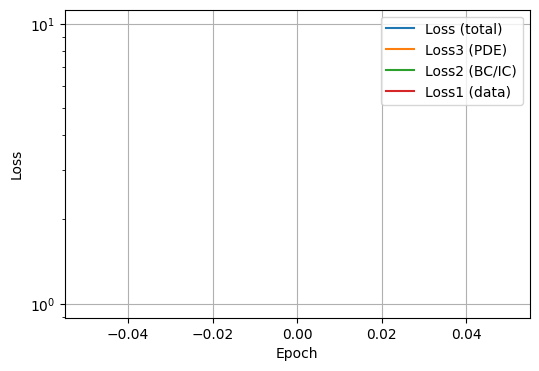

In [29]:
pinn_model = PINN().to(DEVICE)
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.003)
loss_history = []

epochs_hist = []
loss_hist   = []
loss1_hist  = []
loss2_hist  = []
loss3_hist  = []

fig, ax = plt.subplots(figsize=(6, 4))

(line_loss,)  = ax.plot([], [], label="Loss (total)")
(line_l3,)    = ax.plot([], [], label="Loss3 (PDE)")
(line_l2,)    = ax.plot([], [], label="Loss2 (BC/IC)")
(line_l1,)    = ax.plot([], [], label="Loss1 (data)")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.grid(True)
ax.legend()

def update_loss_plot(epoch, loss, loss1, loss2, loss3):
    # store history
    epochs_hist.append(epoch)
    loss_hist.append(loss.cpu().detach().numpy())
    loss1_hist.append(loss1.cpu().detach().numpy())
    loss2_hist.append(loss2.cpu().detach().numpy())
    loss3_hist.append(loss3.cpu().detach().numpy())

    # update line data
    line_loss.set_data(epochs_hist, loss_hist)
    line_l1.set_data(epochs_hist, loss1_hist)
    line_l2.set_data(epochs_hist, loss2_hist)
    line_l3.set_data(epochs_hist, loss3_hist)

    # rescale
    ax.relim()
    ax.autoscale_view()

    clear_output(wait=True)
    display(fig)

  0%|          | 0/20000 [00:00<?, ?it/s]

epoch: 0	loss: (9.183154106140137, 4.264779567718506, 4.913018226623535, 0.0053567225113511086)	
8.978822e-07 0.9999981 5.2852556e-08 

epoch: 250	loss: (0.3721805810928345, 0.09287391602993011, 0.24140308797359467, 0.0379035621881485)	
0.33300114 0.48506895 0.18192947 

epoch: 500	loss: (0.2791599929332733, 0.10652072727680206, 0.16577038168907166, 0.00686886440962553)	
0.38395005 0.4688598 0.14718974 

epoch: 750	loss: (0.23912720382213593, 0.11157965660095215, 0.12314989417791367, 0.0043976400047540665)	
0.3570406 0.47987738 0.16308157 

epoch: 1000	loss: (0.21828073263168335, 0.11573538184165955, 0.09966873377561569, 0.002876612823456526)	
0.5460808 0.27445415 0.17946471 

epoch: 1250	loss: (0.1917334794998169, 0.08932577818632126, 0.1006217673420906, 0.001785933505743742)	
0.50270504 0.3041497 0.19314498 

epoch: 1500	loss: (0.17224512994289398, 0.06395234167575836, 0.10684908181428909, 0.001443699118681252)	
0.52042794 0.38558272 0.093988895 

epoch: 1750	loss: (0.149722918868064

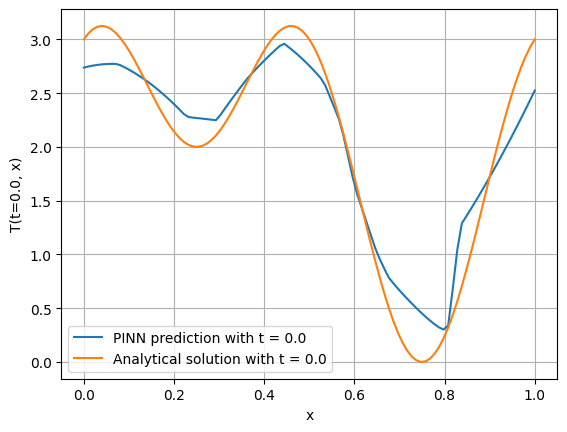

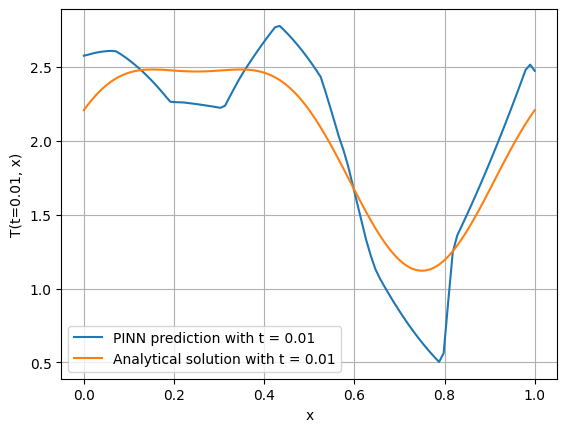

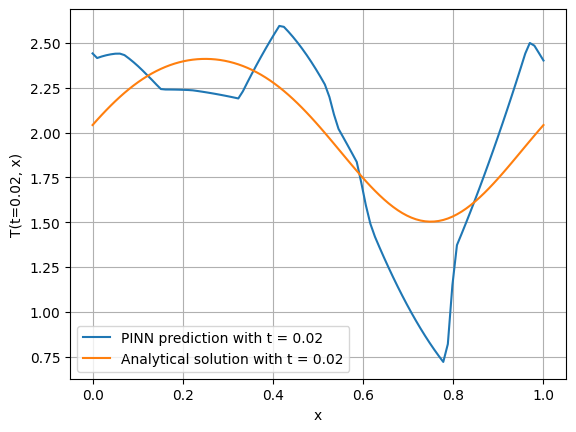

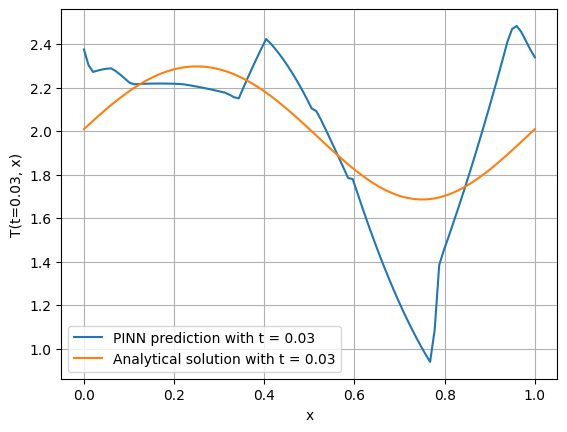

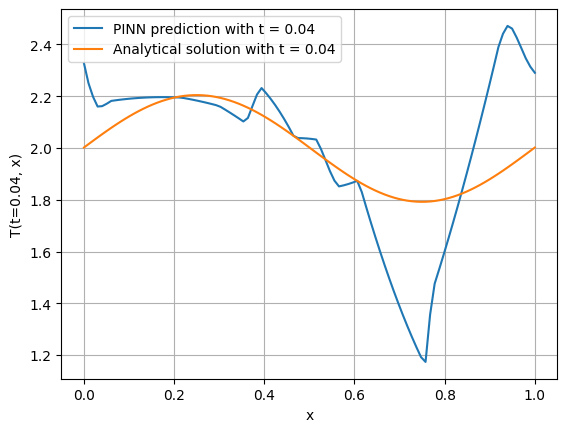

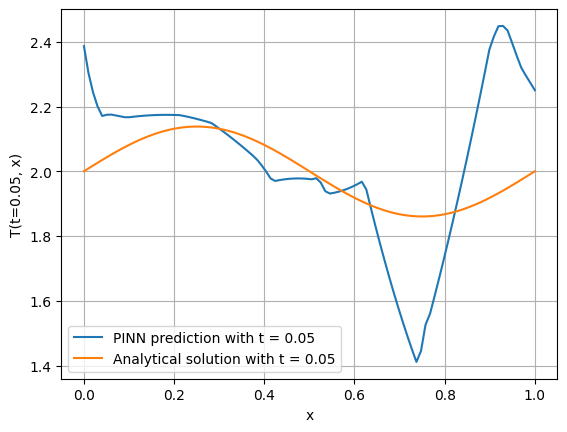

epoch: 3000	loss: (0.10926201939582825, 0.029569420963525772, 0.07852056622505188, 0.0011720366310328245)	
0.62107134 0.2560857 0.12284276 

epoch: 3250	loss: (0.06997818499803543, 0.026234960183501244, 0.040428828448057175, 0.0033143959008157253)	
0.19167209 0.24751146 0.5608162 

epoch: 3500	loss: (0.0654878318309784, 0.024141905829310417, 0.038750600069761276, 0.0025953256990760565)	
0.31370956 0.22289881 0.4633914 

epoch: 3750	loss: (0.05820433422923088, 0.022584320977330208, 0.03516914322972298, 0.00045086696627549827)	
0.64901316 0.27892828 0.07205828 

epoch: 4000	loss: (0.05599353834986687, 0.022331729531288147, 0.03300895541906357, 0.000652852701023221)	
0.49546778 0.34348503 0.16104683 

epoch: 4250	loss: (0.05234571546316147, 0.023047156631946564, 0.028872709721326828, 0.00042585073970258236)	
0.6522215 0.26027617 0.08750215 

epoch: 4500	loss: (0.050951097160577774, 0.017187921330332756, 0.03297899663448334, 0.0007841784972697496)	
0.56983083 0.25213137 0.17803757 

epoch:

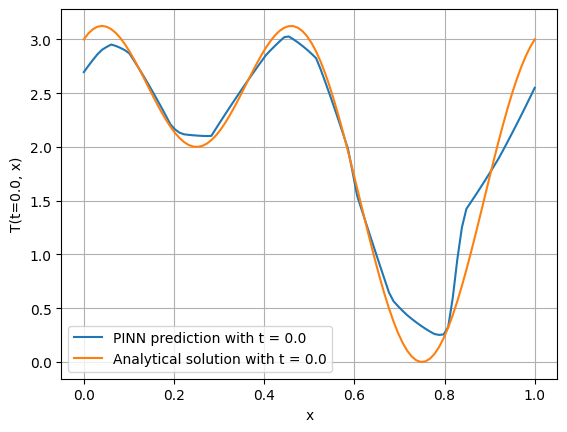

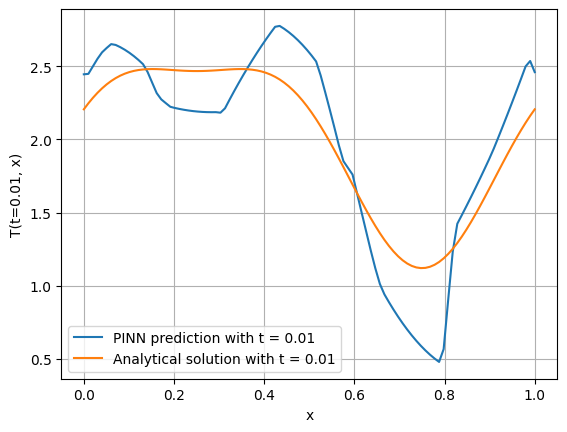

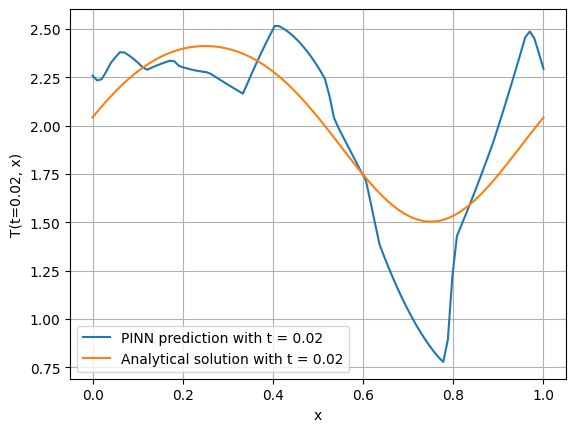

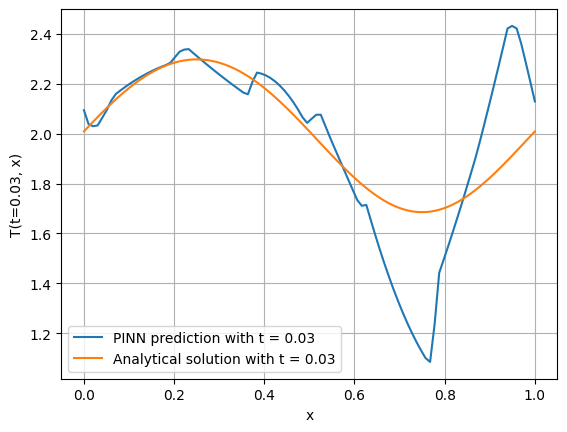

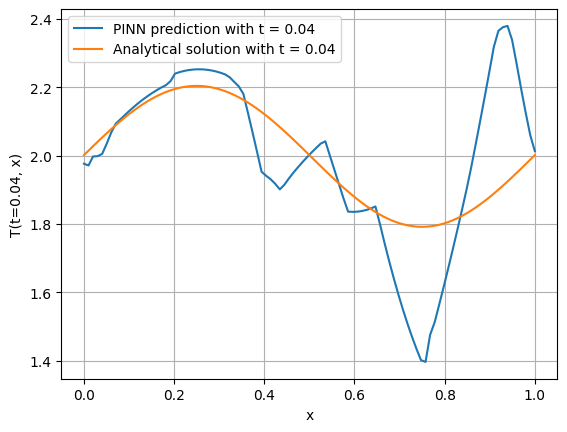

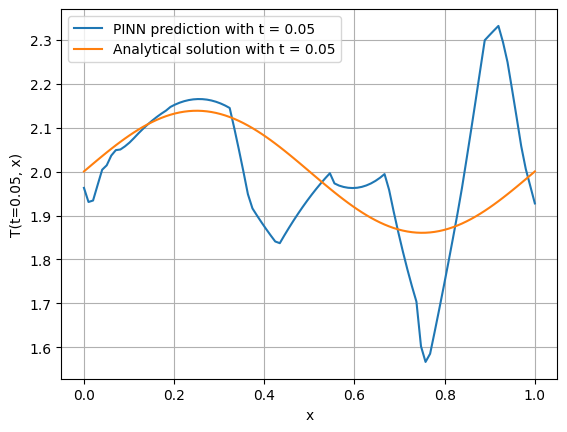

epoch: 6000	loss: (0.04607752710580826, 0.02038183994591236, 0.024129610508680344, 0.001566074090078473)	
0.3535985 0.26332384 0.38307747 

epoch: 6250	loss: (0.11224133521318436, 0.033227819949388504, 0.07717469334602356, 0.001838826690800488)	
0.654399 0.22538151 0.120219275 

epoch: 6500	loss: (0.06407032907009125, 0.016171462833881378, 0.04578493535518646, 0.0021139299497008324)	
0.5578285 0.20771423 0.23445708 

epoch: 6750	loss: (0.03843856602907181, 0.01603066921234131, 0.021387048065662384, 0.001020848285406828)	
0.5323776 0.33376065 0.13386141 

epoch: 7000	loss: (0.08496278524398804, 0.017039509490132332, 0.06456457823514938, 0.003358695888891816)	
0.26394105 0.21571277 0.5203459 

epoch: 7250	loss: (0.04178265854716301, 0.017773063853383064, 0.019359903410077095, 0.004649690818041563)	
0.44685724 0.22997458 0.32316795 

epoch: 7500	loss: (0.037201620638370514, 0.016070492565631866, 0.02017015963792801, 0.0009609668049961329)	
0.42052835 0.29120502 0.2882664 

epoch: 7750	los

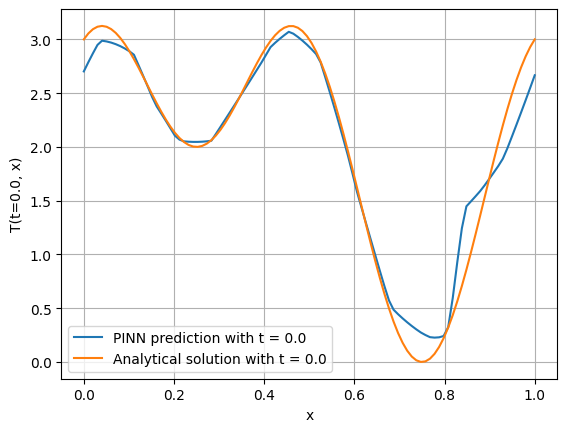

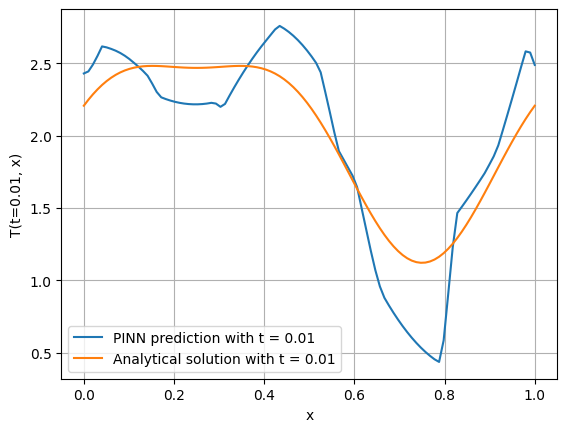

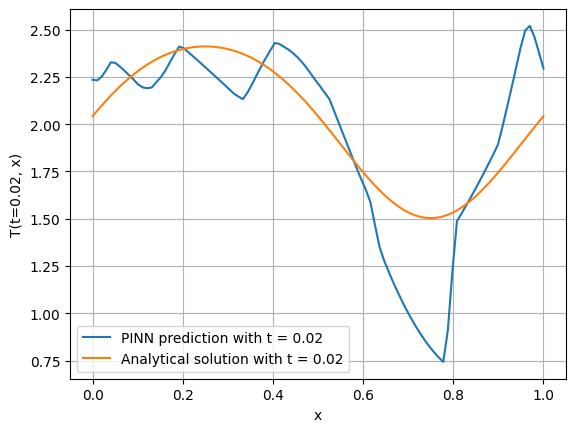

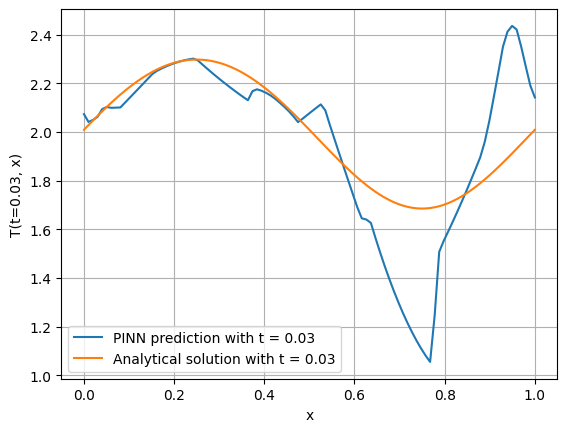

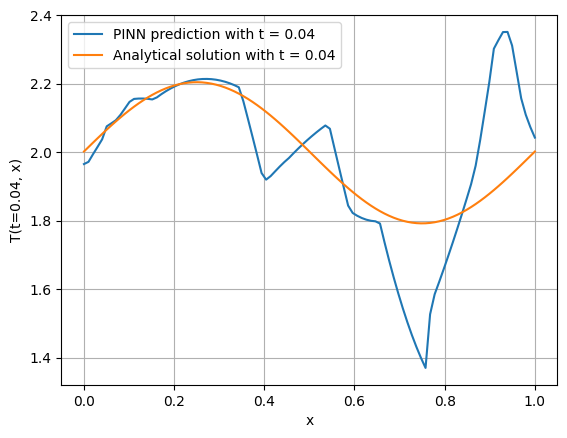

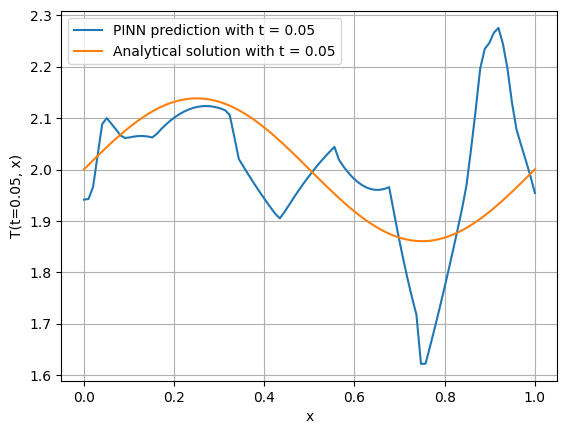

epoch: 9000	loss: (0.038369257003068924, 0.01477587316185236, 0.020171234384179115, 0.0034221482928842306)	
0.2881555 0.26117095 0.45067334 

epoch: 9250	loss: (0.02922505885362625, 0.014766900800168514, 0.010873233899474144, 0.003584924852475524)	
0.13153578 0.21633807 0.65212595 

epoch: 9500	loss: (0.03119245544075966, 0.011363319121301174, 0.013944660313427448, 0.005884475074708462)	
0.16339763 0.22034752 0.6162546 

epoch: 9750	loss: (0.027389293536543846, 0.01123229879885912, 0.012969153001904488, 0.0031878408044576645)	
0.22370334 0.19764803 0.57864845 

epoch: 10000	loss: (0.02793104574084282, 0.010288114659488201, 0.015914607793092728, 0.0017283224733546376)	
0.23195668 0.3302623 0.4377807 

epoch: 10250	loss: (0.025985103100538254, 0.012418461963534355, 0.010271408595144749, 0.003295231843367219)	
0.14209054 0.20861031 0.64929897 

epoch: 10500	loss: (0.027136780321598053, 0.011660506948828697, 0.012886968441307545, 0.002589303068816662)	
0.31807536 0.24996054 0.4319638 

epo

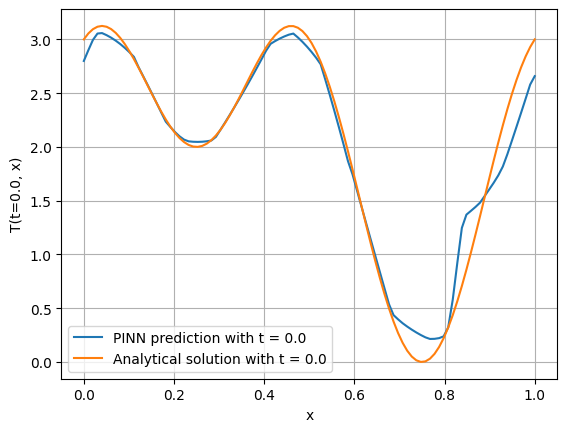

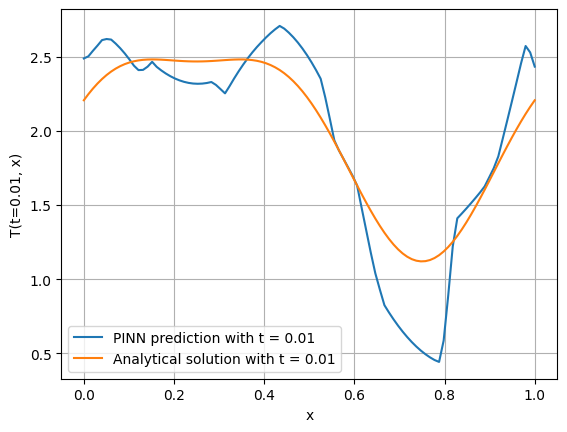

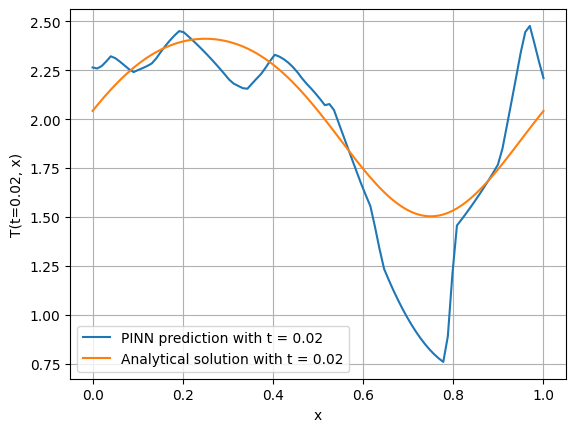

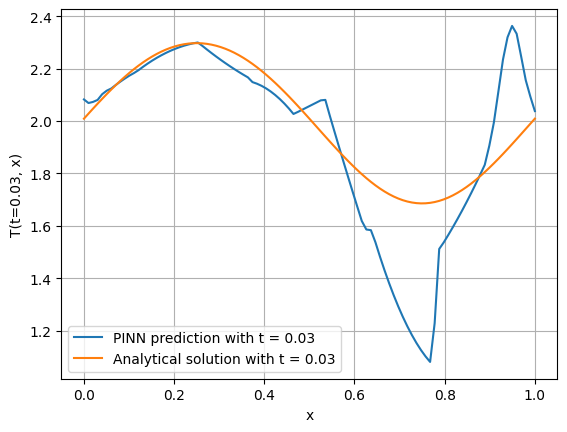

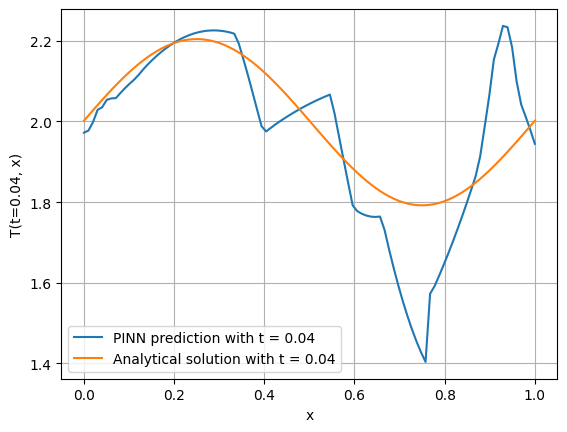

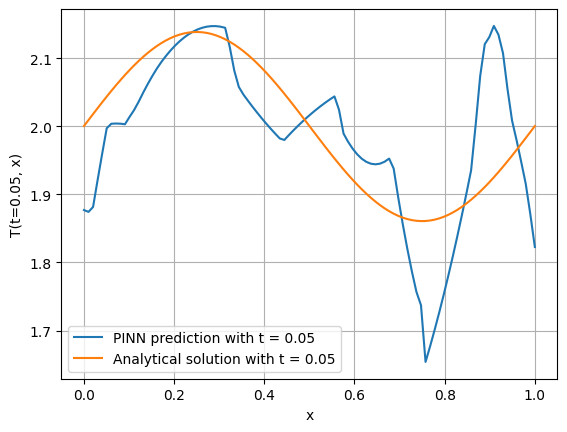

epoch: 12000	loss: (0.02384241670370102, 0.008856939151883125, 0.013445429503917694, 0.001540047232992947)	
0.22022128 0.27084014 0.5089383 

epoch: 12250	loss: (0.02962169423699379, 0.011858434416353703, 0.016263553872704506, 0.0014997043181210756)	
0.56320435 0.28147835 0.15531707 

epoch: 12500	loss: (0.026883117854595184, 0.009340859018266201, 0.01311864610761404, 0.004423612728714943)	
0.14727066 0.1745428 0.6781864 

epoch: 12750	loss: (0.019353479146957397, 0.007849459536373615, 0.010192569345235825, 0.0013114517787471414)	
0.39908236 0.3553394 0.2455779 

epoch: 13000	loss: (0.022003287449479103, 0.007874623872339725, 0.012770798057317734, 0.001357866683974862)	
0.43630114 0.31057152 0.25312704 

epoch: 13250	loss: (0.01868927851319313, 0.006897020153701305, 0.009017047472298145, 0.002775210188701749)	
0.20804316 0.20280683 0.5891498 

epoch: 13500	loss: (0.017079874873161316, 0.007898644544184208, 0.005415196530520916, 0.0037660328671336174)	
0.10170773 0.18284991 0.7154421 



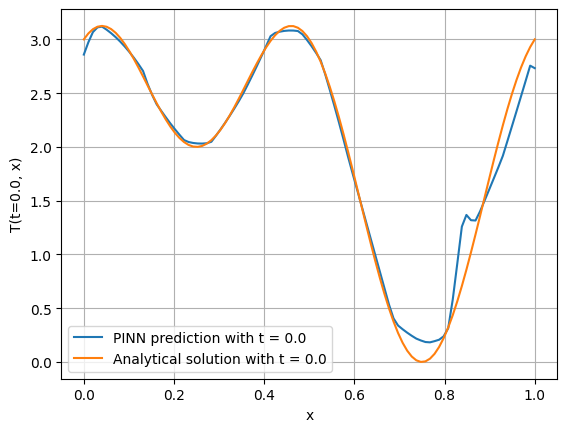

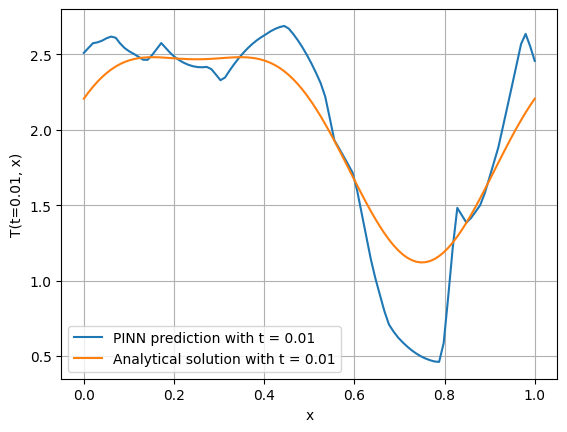

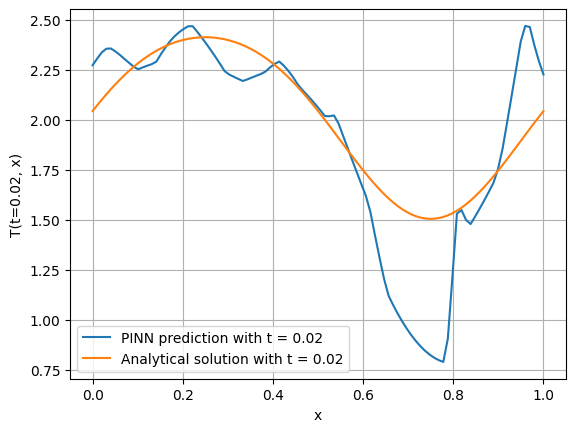

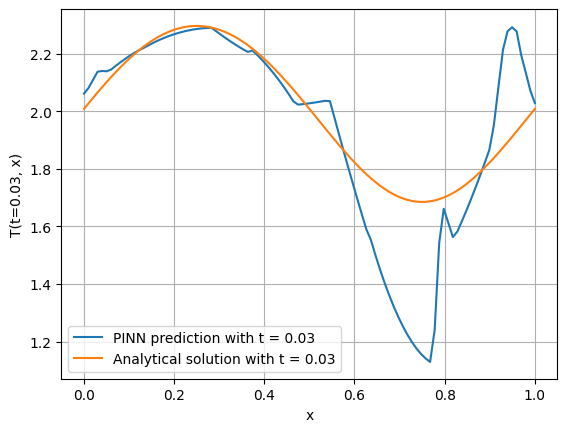

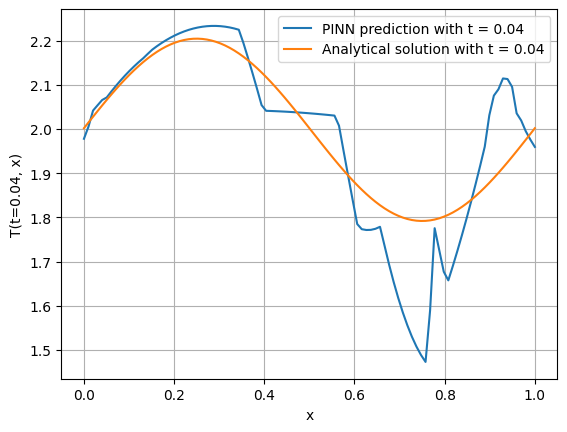

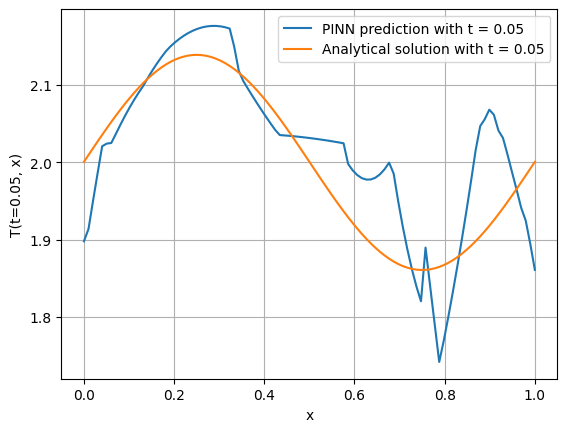

epoch: 15000	loss: (0.013293796218931675, 0.007151678670197725, 0.004114119801670313, 0.0020279979798942804)	
0.11917394 0.21808751 0.6627384 

epoch: 15250	loss: (0.02744818851351738, 0.008867601864039898, 0.0173642598092556, 0.0012163262581452727)	
0.327362 0.3945551 0.27808258 

epoch: 15500	loss: (0.012333981692790985, 0.005938087590038776, 0.005870435852557421, 0.0005254574352875352)	
0.4722217 0.38114297 0.14663492 

epoch: 15750	loss: (0.018117757514119148, 0.006736580282449722, 0.010605565272271633, 0.0007756117265671492)	
0.3285582 0.30698234 0.3644592 

epoch: 16000	loss: (0.011667649261653423, 0.006692441180348396, 0.002919822931289673, 0.0020553849171847105)	
0.17476083 0.20117183 0.62406707 

epoch: 16250	loss: (0.010837526060640812, 0.006167144048959017, 0.003416916122660041, 0.0012534658890217543)	
0.1460586 0.24961644 0.60432476 



In [ ]:
epochs = 20_000
loss_prev = None
for cur_epoch in trange(epochs):
    
    optimizer.zero_grad()
    
    boundary_condition_temp = pinn_model(boundary_condition_points)
    network_temp = pinn_model(points_for_pinn_model)
    periodic_temp_0 = pinn_model(periodic_points_x0)
    periodic_temp_1 = pinn_model(periodic_points_x1)
    
    loss1 = torch.mean(
        (thermal_conductivity_equation([time_physics, x_physics]).view(-1,1) - network_temp)**2
    )
    
    loss2 = torch.mean(
        (thermal_conductivity_equation([torch.zeros_like(time_physics), x_physics]).view(-1,1) - boundary_condition_temp)**2 +
        (periodic_temp_0 - periodic_temp_1)**2
    )

    network_temp = pinn_model(points_for_pinn_model)
    
    dt = torch.autograd.grad(network_temp, time_physics, torch.ones_like(network_temp), create_graph=True, allow_unused=False)[0]
    dx = torch.autograd.grad(network_temp, x_physics, torch.ones_like(network_temp), create_graph=True, allow_unused=False)[0]
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True, allow_unused=False)[0]

    
    loss3 = torch.mean((dt - dx2)**2)
    dist = loss1+loss2+loss3

    w2, w3, w1 = compute_weights_grad_orthogonal_autograd(
        pinn_model, loss2, loss3, loss1, kappa=3.0, eps=1e-6
    )

    loss = w1*loss1 + w2*loss2 + w3*loss3
    
    loss.backward(retain_graph=True)
    loss_history.append(float(dist.cpu().detach().numpy()))
    torch.nn.utils.clip_grad_norm_(pinn_model.parameters(), max_norm=1.0)
    optimizer.step()
    dist = loss1 + loss2 + loss3
    # update_loss_plot(cur_epoch, loss, loss1, loss2, loss3)
    if loss_prev == None or loss_prev >= loss:
        torch.save(pinn_model.state_dict(), f'pinn_model_weights_{N}.pth')
    if cur_epoch % 3_000  == 0 and cur_epoch != 0:
        optimizer.param_groups[0]['lr'] *= 0.9
        check_current_situation(pinn_model, t=0.0)
        check_current_situation(pinn_model, t=0.01)
        check_current_situation(pinn_model, t=0.02)
        check_current_situation(pinn_model, t=0.03)
        check_current_situation(pinn_model, t=0.04)
        check_current_situation(pinn_model, t=0.05)
    if cur_epoch % 250 == 0:
        print(f'epoch: {cur_epoch}\tloss: {float(dist.cpu().detach().numpy()), float(loss1.cpu().detach().numpy()), float(loss2.cpu().detach().numpy()), float(loss3.cpu().detach().numpy())}\t')
        print(w1, w2, w3,'\n')

In [ ]:
print(f'pinn_model_weights_{N}')
print(x_physics.shape)

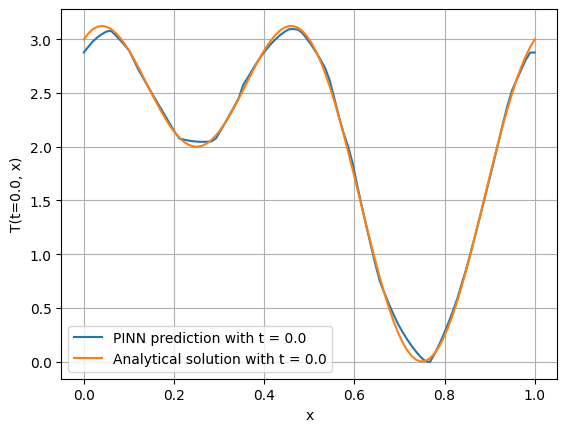

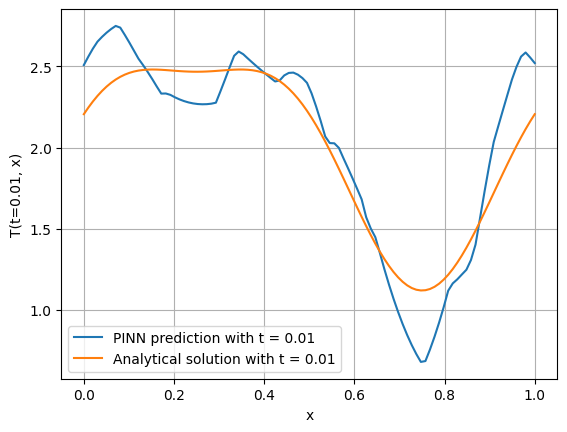

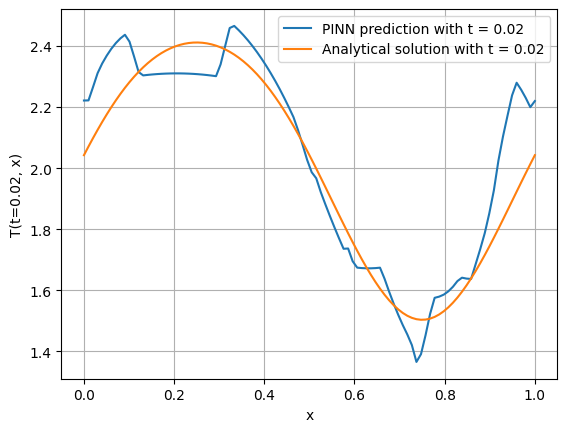

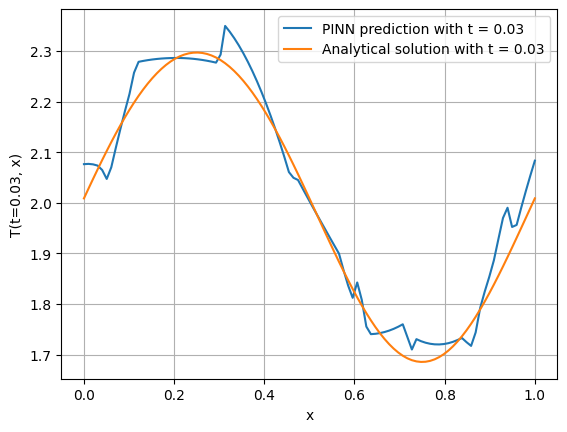

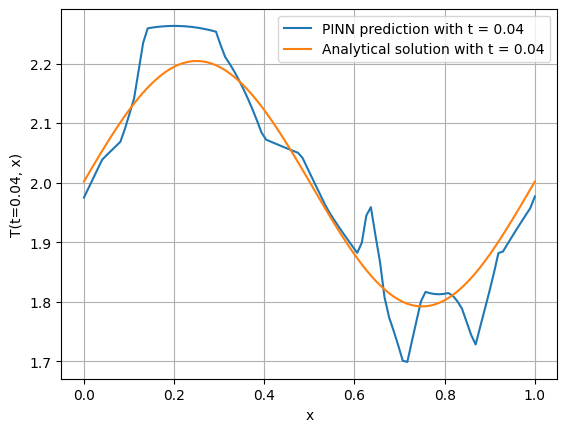

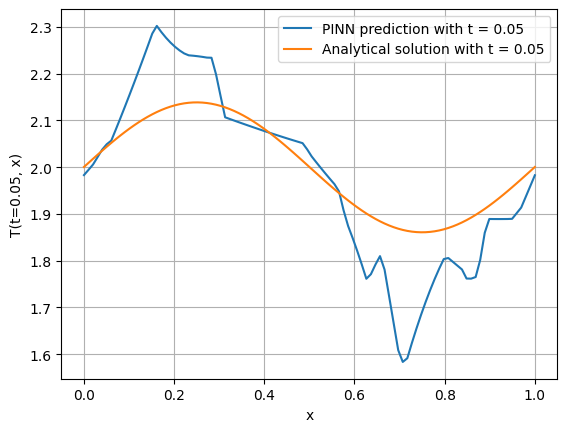

In [16]:
check_current_situation(pinn_model, t=0.0)
check_current_situation(pinn_model, t=0.01)
check_current_situation(pinn_model, t=0.02)
check_current_situation(pinn_model, t=0.03)
check_current_situation(pinn_model, t=0.04)
check_current_situation(pinn_model, t=0.05)

In [15]:
x_physics.shape

torch.Size([5000])

# SVM

In [16]:
def check_current_situation_svm(svm_model, scaler, t=0):
    x = np.linspace(0, 1, 100)
    time = t * np.ones(100)
    real_temp = thermal_conductivity_equation([torch.tensor(time), torch.tensor(x)])

    test_points = np.stack((time, x), axis = -1)

    svm_pred = svm_model.predict(scaler.transform(test_points))

    plt.plot(x, svm_pred, label=f'SVM prediction with t = {t}')
    plt.plot(x, real_temp, label=f'Analytical solution with t = {t}')
    plt.grid()
    plt.xlabel('x')
    plt.ylabel(f'T(t={t}, x)')

    plt.plot()
    plt.legend()
    plt.show()

In [19]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

x_svm = x_physics.cpu().detach().numpy()
time_svm = time_physics.cpu().detach().numpy()

X_train = points_for_pinn_model.cpu().detach().numpy()
y_train = thermal_conductivity_equation([points_for_pinn_model[:, 0], points_for_pinn_model[:, 1]]).cpu().detach().numpy()

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

svr = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")

svr.fit(X_train_scaled, y_train)
# y_pred = svr.predict(X_test_scaled)
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("R^2:", r2_score(y_test, y_pred))

SVR()

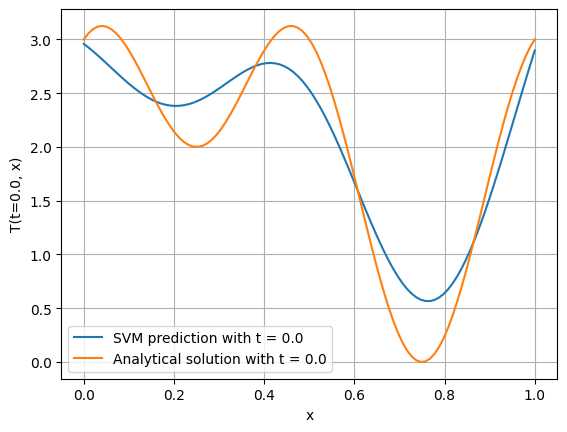

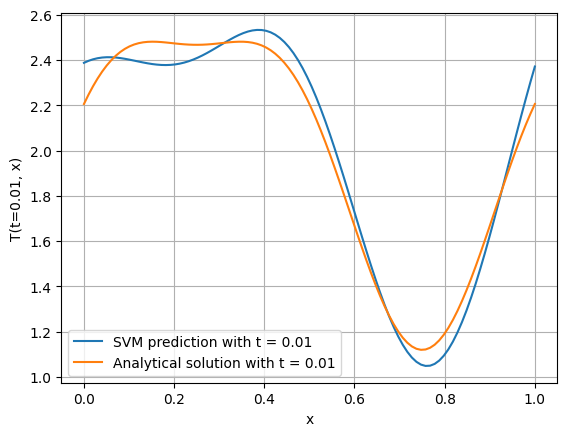

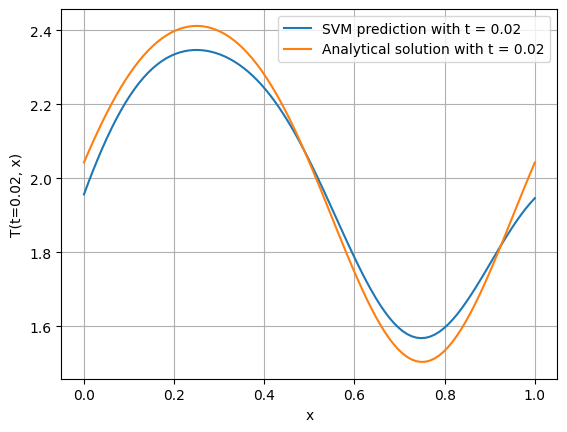

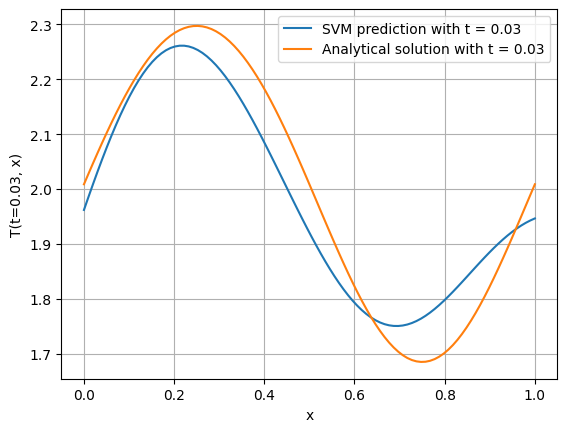

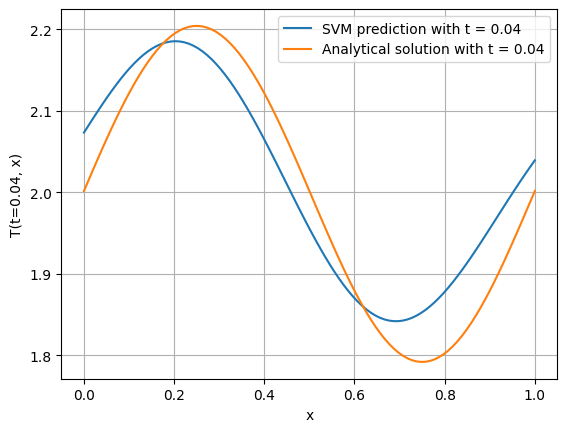

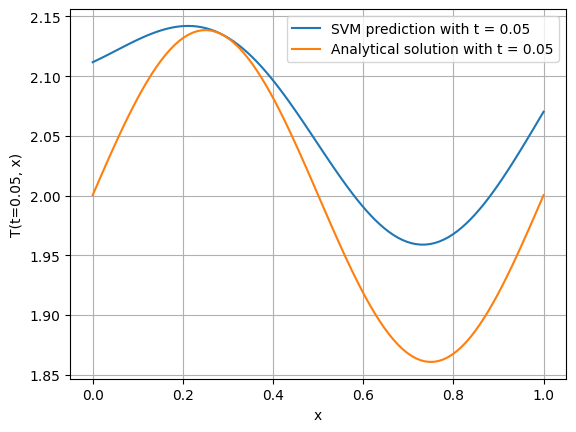

In [20]:
check_current_situation_svm(svr, scaler, t=0.0)
check_current_situation_svm(svr, scaler, t=0.01)
check_current_situation_svm(svr, scaler, t=0.02)
check_current_situation_svm(svr, scaler, t=0.03)
check_current_situation_svm(svr, scaler, t=0.04)
check_current_situation_svm(svr, scaler, t=0.05)